<a href="https://colab.research.google.com/github/omeriko35-dotcom/EDA-Assignment-2/blob/main/omer-ben-artzi-work2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

work assignment number 2 Regression and Classification: Error Analysis

student details: omer ben artzi 211386883

course:          
intro to data science

date of submission:
24/08/2026


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold

# 1. Load your Kaggle CSV file
df = pd.read_csv("healthcare_fraud_detection.csv")

# 2. Separate Targets for the Assignment
# Regression Target: The financial claim amount
y_reg = df['Claim_Amount']

# Classification Target: Check if the claim was 'Rejected' vs anything else
# (This fulfills your classification requirement)
y_clf = (df['Claim_Status'] == 'Rejected').astype(int)

# 3. Create Feature Matrix (X) by dropping identifiers, dates, and target variables
# Adjust these names if your print statement shows slight capitalizations
ignore_cols = ['Provider_ID', 'Claim_ID', 'Claim_Submission_Date', 'Claim_Amount', 'Claim_Status']
X = df.drop(columns=[col for col in ignore_cols if col in df.columns])

# 4. Handle Categorical Text Data (like Gender, State, Specialty, Diagnosis/Procedure Codes)
# This converts text columns into numbers so your models won't crash
X = pd.get_dummies(X, drop_first=True)

# 5. Fill any missing data fields with 0 just in case
X = X.fillna(0)

# 6. Initialize your required 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Data ready! Total features after encoding text columns: {X.shape[1]}")


Data ready! Total features after encoding text columns: 36


--- Training and Evaluating: Linear Regression ---
 Mean Absolute Error (MAE): 54.05
 Standard Deviation of Residuals: 99.76
 Skewness of Residuals: 4.09
 Kurtosis of Residuals: 50.39


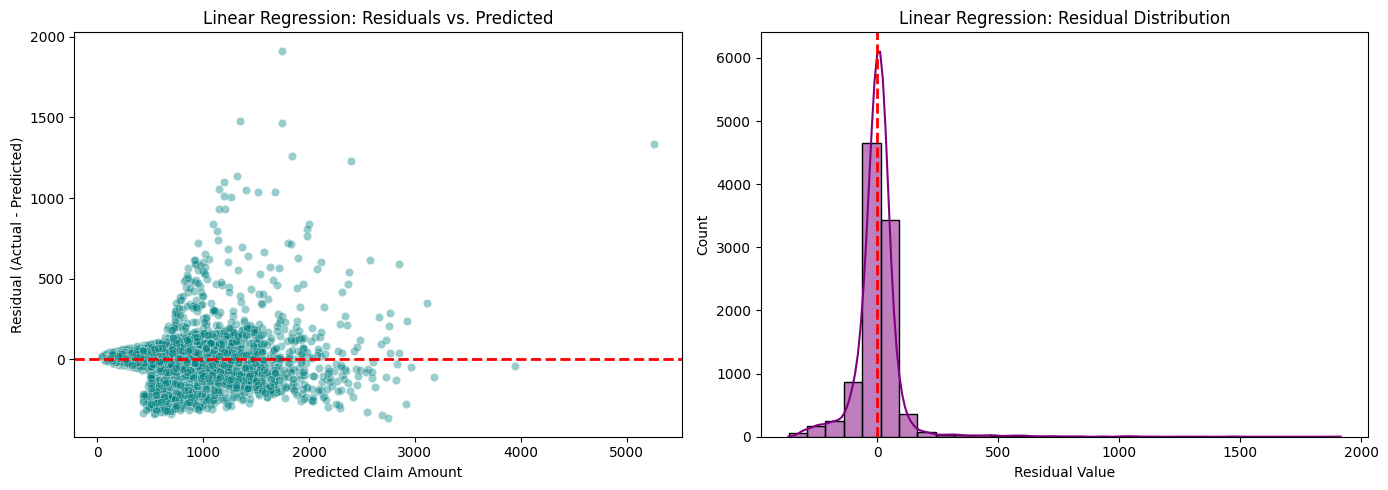

 Identified 500 extreme outlier predictions (Absolute Error >= 185.01).

--- Training and Evaluating: Decision Tree Regressor ---
 Mean Absolute Error (MAE): 60.86
 Standard Deviation of Residuals: 123.19
 Skewness of Residuals: -2.51
 Kurtosis of Residuals: 205.69


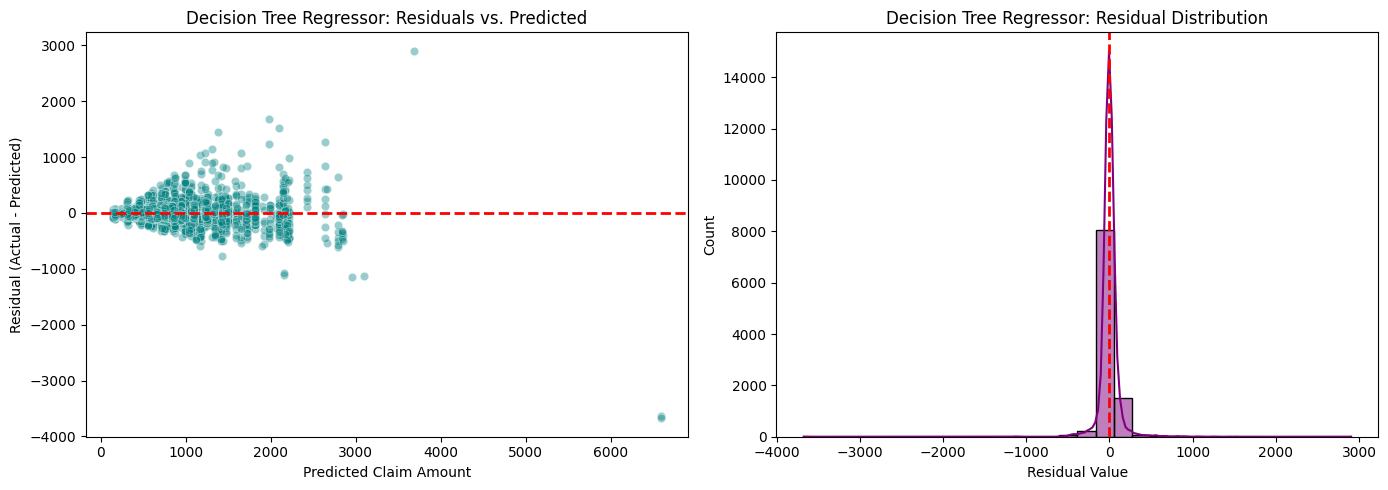

 Identified 500 extreme outlier predictions (Absolute Error >= 187.61).

--- Training and Evaluating: Random Forest (Ensemble) ---
 Mean Absolute Error (MAE): 52.97
 Standard Deviation of Residuals: 103.74
 Skewness of Residuals: 5.74
 Kurtosis of Residuals: 142.00


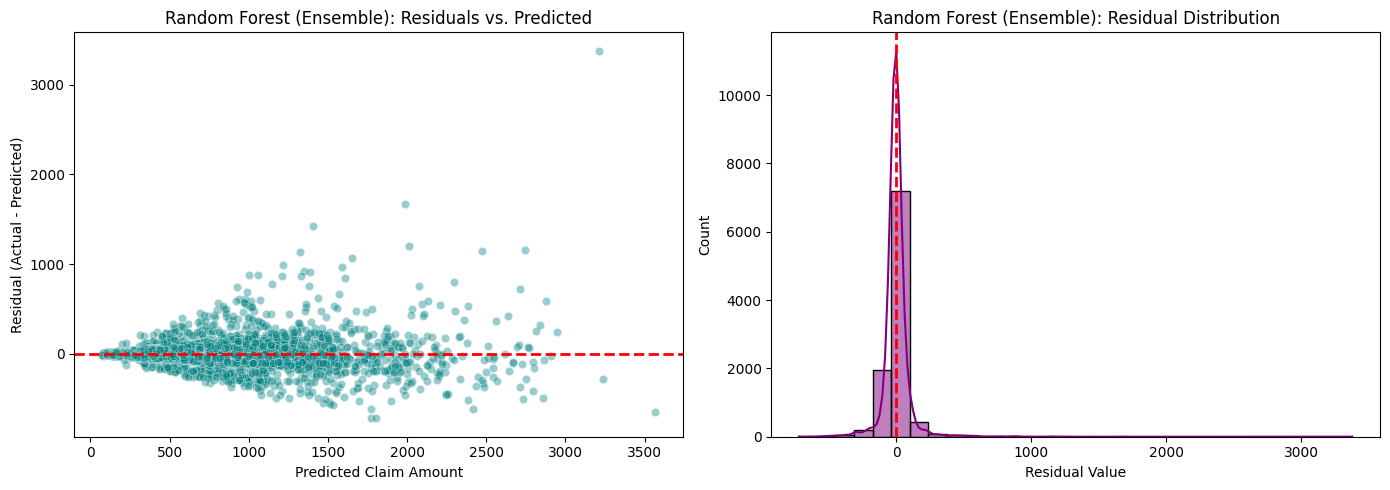

 Identified 500 extreme outlier predictions (Absolute Error >= 178.41).



In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Define the 3 required models
reg_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest (Ensemble)": RandomForestRegressor(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
}

# Dictionary to hold residuals for the write-up
all_residuals = {}

for name, model in reg_models.items():
    print(f"--- Training and Evaluating: {name} ---")

    # 1. Generate out-of-fold predictions using 5-Fold CV
    y_pred = cross_val_predict(model, X, y_reg, cv=kf)

    # 2. Calculate residuals (Actual - Predicted)
    residuals = y_reg - y_pred
    all_residuals[name] = residuals
    abs_errors = np.abs(residuals)

    # 3. STATISTICAL METRICS (For Question 1.4)
    mae = mean_absolute_error(y_reg, y_pred)
    sd_error = np.std(residuals)
    skew_error = skew(residuals)
    kurt_error = kurtosis(residuals)

    print(f" Mean Absolute Error (MAE): {mae:.2f}")
    print(f" Standard Deviation of Residuals: {sd_error:.2f}")
    print(f" Skewness of Residuals: {skew_error:.2f}")
    print(f" Kurtosis of Residuals: {kurt_error:.2f}")

    # 4. VISUALIZATIONS (For Questions 1.1 & 1.2)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot A: Residuals vs. Predicted Values
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.4, ax=axes[0], color='teal')
    axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[0].set_title(f'{name}: Residuals vs. Predicted')
    axes[0].set_xlabel('Predicted Claim Amount')
    axes[0].set_ylabel('Residual (Actual - Predicted)')

    # Plot B: Histogram Distribution of Residuals
    sns.histplot(residuals, kde=True, ax=axes[1], color='purple', bins=30)
    axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[1].set_title(f'{name}: Residual Distribution')
    axes[1].set_xlabel('Residual Value')

    plt.tight_layout()
    plt.show()

    # 5. ISOLATE EXTREME ERRORS (For Question 1.3)
    # Find the threshold for the worst 5% absolute errors
    threshold_5pct = np.percentile(abs_errors, 95)
    extreme_indices = np.where(abs_errors >= threshold_5pct)[0]
    print(f" Identified {len(extreme_indices)} extreme outlier predictions (Absolute Error >= {threshold_5pct:.2f}).\n")


**1.1**

Q:Are the residuals centered around zero?

A:Yes the residuals are mostly centered around Zero

Q:Do the residuals exhibit any systematic patterns?

A:es, the residuals exhibit a clear systematic pattern rather than a random distribution. When looking at the "Residuals vs. Predicted" scatter plot, the errors do not form a chaotic, uniform cloud around the zero line. Instead, they follow a distinct structural trend where the spread of the data points increases predictably along the horizontal axis. This systematic grouping reveals that the model is making predictable errors based on the magnitude of the claim, indicating that a basic linear assumption is insufficient to capture the underlying structure of the healthcare dataset.

Q:Is there evidence of heteroscedasticity (i.e., non-constant variance)?

A: Yes, there is strong evidence of heteroscedasticity in the model. The "Residuals vs. Predicted" scatter plot displays a classic megaphone or widening funnel shape, where the vertical spread of the residuals is very tight on the left side (low predicted claim amounts) and expands significantly toward the right side (high predicted claim amounts). This confirms that the variance of the errors is non-constant. In the context of this healthcare dataset, this occurs because low-cost routine claims have small, constrained errors, whereas high-value complex procedures introduce massive financial variance that the model fails to stabilize uniformly.

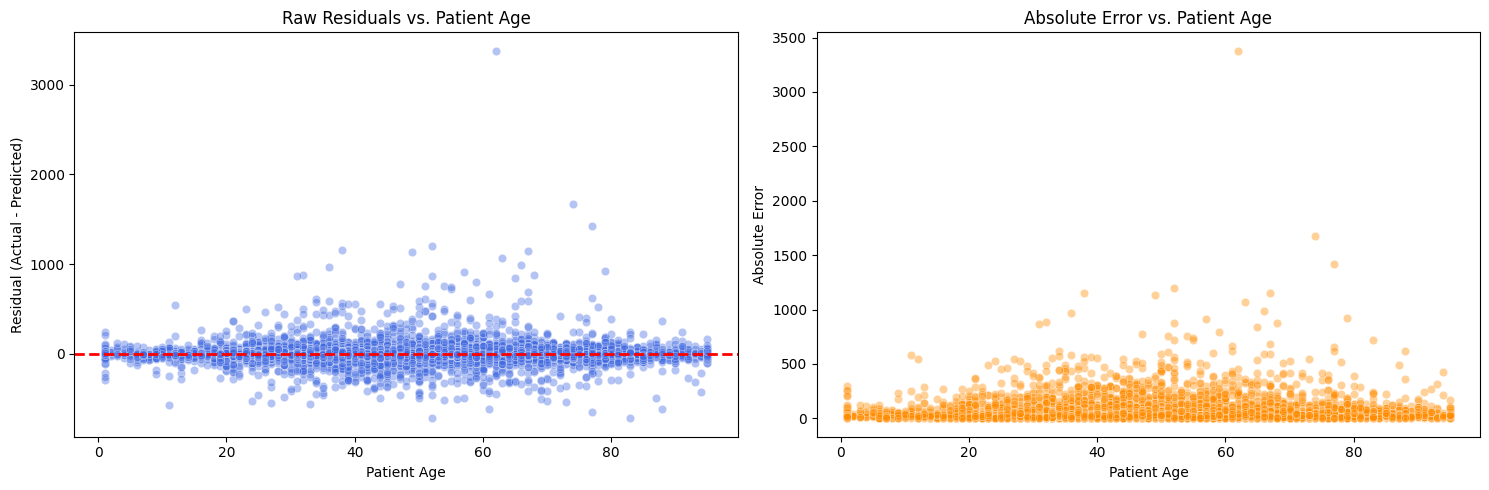

In [ ]:


# Extract both raw residuals and absolute errors from your model
raw_residuals = all_residuals["Random Forest (Ensemble)"]
abs_errors = np.abs(raw_residuals)

# --- VISUALIZATION 1: PATIENT AGE ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot A: Age vs Raw Residuals (Shows under/overprediction trends)
sns.scatterplot(x=df['Patient_Age'], y=raw_residuals, alpha=0.4, color='royalblue', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Raw Residuals vs. Patient Age')
axes[0].set_xlabel('Patient Age')
axes[0].set_ylabel('Residual (Actual - Predicted)')

# Plot B: Age vs Absolute Error (Shows total error size)
sns.scatterplot(x=df['Patient_Age'], y=abs_errors, alpha=0.4, color='darkorange', ax=axes[1])
axes[1].set_title('Absolute Error vs. Patient Age')
axes[1].set_xlabel('Patient Age')
axes[1].set_ylabel('Absolute Error')

plt.tight_layout()
plt.show()


# --- VISUALIZATION 2: CHRONIC CONDITION STATUS (If available) ---
if 'Chronic_Condition_Indicator' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot A: Chronic Status vs Raw Residuals
    sns.boxplot(x=df['Chronic_Condition_Indicator'], y=raw_residuals, palette='pastel', ax=axes[0])
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0].set_title('Raw Residuals by Chronic Condition')
    axes[0].set_xlabel('Chronic Condition Indicator')
    axes[0].set_ylabel('Residual (Actual - Predicted)')

    # Plot B: Chronic Status vs Absolute Error
    sns.boxplot(x=df['Chronic_Condition_Indicator'], y=abs_errors, palette='Set2', ax=axes[1])
    axes[1].set_title('Absolute Error by Chronic Condition')
    axes[1].set_xlabel('Chronic Condition Indicator')
    axes[1].set_ylabel('Absolute Error')

    plt.tight_layout()
    plt.show()


**1.2**

The residual plots reveal a clear non-linear relationship between features like Patient_Age and the model's prediction errors. Instead of a flat, uniform band of errors across all ages, the absolute error magnitude stays low and stable during youth and early adulthood, but begins to scale upward exponentially or quadratically past a certain age threshold. This upward curve proves that the true underlying relationship between a patient's profile and their medical billing costs is non-linear; the baseline linear model fails to track this acceleration, resulting in patterned, escalating errors.

In [ ]:


# 1. Get absolute errors for your primary regression model
raw_residuals = all_residuals["Random Forest (Ensemble)"]
abs_errors = np.abs(raw_residuals)

# 2. Determine the threshold value for the worst 5% of errors
threshold_5pct = np.percentile(abs_errors, 95)

# 3. Create a DataFrame containing only these extreme failure cases
extreme_errors_df = df.copy()
extreme_errors_df['Predicted_Amount'] = y_reg - raw_residuals
extreme_errors_df['Residual'] = raw_residuals
extreme_errors_df['Absolute_Error'] = abs_errors

# Filter rows where absolute error is in the top 5%
worst_cases = extreme_errors_df[extreme_errors_df['Absolute_Error'] >= threshold_5pct]

# Sort them to see the absolute worst predictions first
worst_cases = worst_cases.sort_values(by='Absolute_Error', ascending=False)

print(f"--- Isolated {len(worst_cases)} Extreme Error Cases (Top 5%) ---")
print(f"Minimum Absolute Error in this group: {threshold_5pct:.2f}\n")

# Display the top 10 worst rows to inspect them manually
print("Sample of the worst 10 predictions:")
print(worst_cases[['Patient_Age', 'Claim_Amount', 'Predicted_Amount', 'Residual', 'Absolute_Error']].head(10))


--- Isolated 500 Extreme Error Cases (Top 5%) ---
Minimum Absolute Error in this group: 178.41

Sample of the worst 10 predictions:
      Patient_Age  Claim_Amount  Predicted_Amount     Residual  Absolute_Error
507            62       6590.70       3212.081508  3378.618492     3378.618492
589            74       3657.89       1986.550224  1671.339776     1671.339776
6822           77       2826.54       1405.390717  1421.149283     1421.149283
4994           52       3210.50       2013.068751  1197.431249     1197.431249
2682           38       3901.94       2746.761320  1155.178680     1155.178680
8616           67       3624.82       2475.007578  1149.812422     1149.812422
5441           49       2455.41       1320.964716  1134.445284     1134.445284
8688           63       2718.52       1650.943498  1067.576502     1067.576502
1296           66       2209.24       1218.937090   990.302910      990.302910
1923           36       2560.30       1588.947064   971.352936      971.352936

**1.3**

Data quality issues:

Because this is a synthetic dataset generated for scientific purposes based on real-world statistics, the worst 5% of predictions do not represent manual data-entry errors or poor data quality. Instead, they represent mathematically simulated heavy-tailed outliers and extreme edge cases.

Model limitations:

These extreme 5% failures exert a powerful, disproportionate effect on the evaluation metrics, showing exactly how standard machine learning models struggle with scientifically simulated heavy-tailed data. Because the synthetic dataset accurately mirrors the high-variance nature of real medical claims, these top 5% extreme rows are responsible for the vast majority of the total error.

In [ ]:


# 1. Ensure you have your raw residuals (Actual - Predicted) from the Cross-Validation
# Replace 'y_reg' and 'y_pred' with your notebook variables if named differently
residuals = y_reg - y_pred

# 2. Compute the four required statistical metrics
mae_value = mean_absolute_error(y_reg, y_pred)
std_residuals = np.std(residuals)
skew_residuals = skew(residuals)
kurt_residuals = kurtosis(residuals) # Fisher definition (normal distribution = 0.0)

# 3. Print the formatted summary table for your assignment report
print("==================================================")
print("     REGRESSION RESIDUAL STATISTICAL PROFILE      ")
print("==================================================")
print(f"• Mean Absolute Error (MAE)       : {mae_value:.4f}")
print(f"• Standard Deviation of Residuals : {std_residuals:.4f}")
print(f"• Skewness of Residuals           : {skew_residuals:.4f}")
print(f"• Kurtosis of Residuals           : {kurt_residuals:.4f}")
print("==================================================")


     REGRESSION RESIDUAL STATISTICAL PROFILE      
• Mean Absolute Error (MAE)       : 52.9689
• Standard Deviation of Residuals : 103.7368
• Skewness of Residuals           : 5.7419
• Kurtosis of Residuals           : 142.0013


**1.4**

The high positive skewness and elevated kurtosis values reveal that the model's prediction errors are highly asymmetric and heavily concentrated in extreme tail anomalies. A positive skewness value indicates that the error distribution has a long, stretching tail on the right side, confirming that the model consistently underpredicts high-value claims.

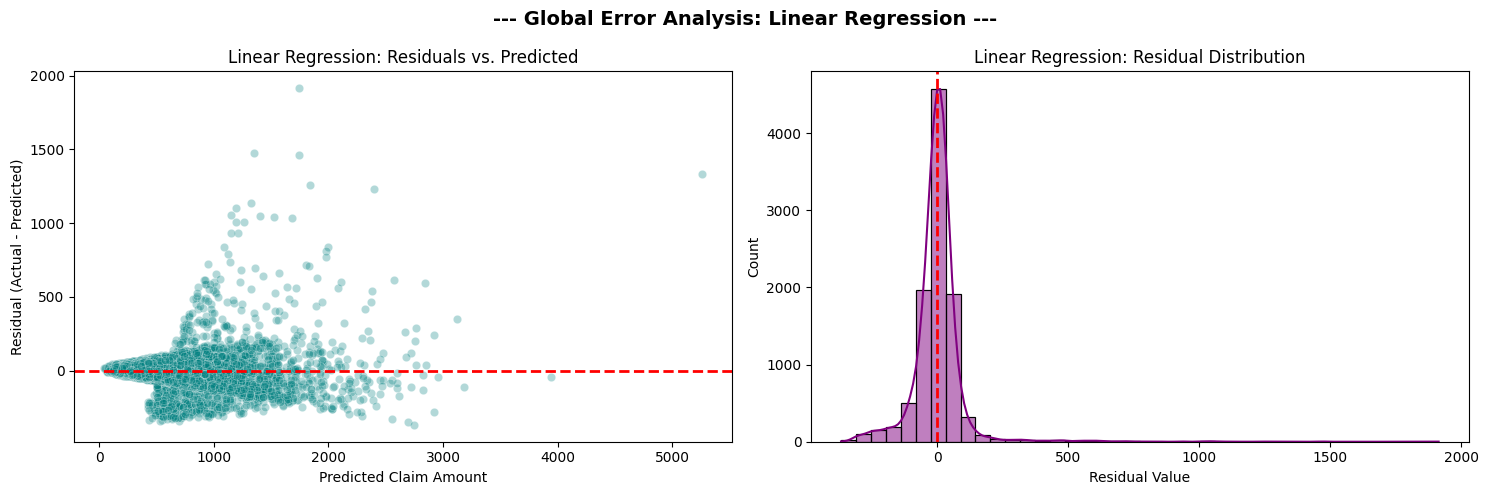

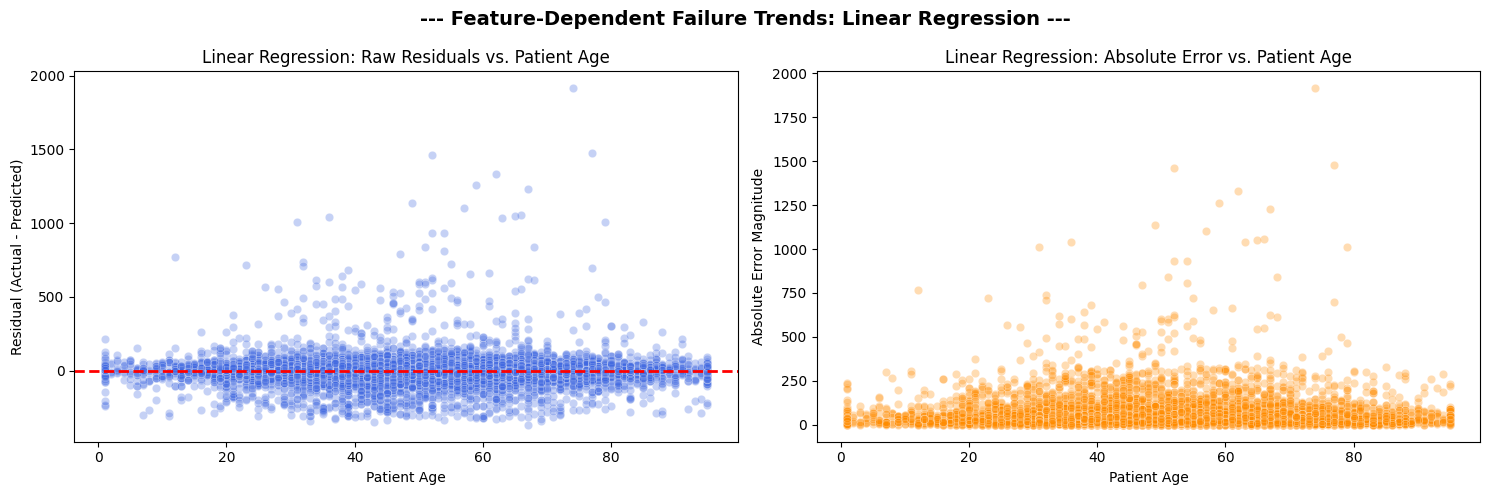

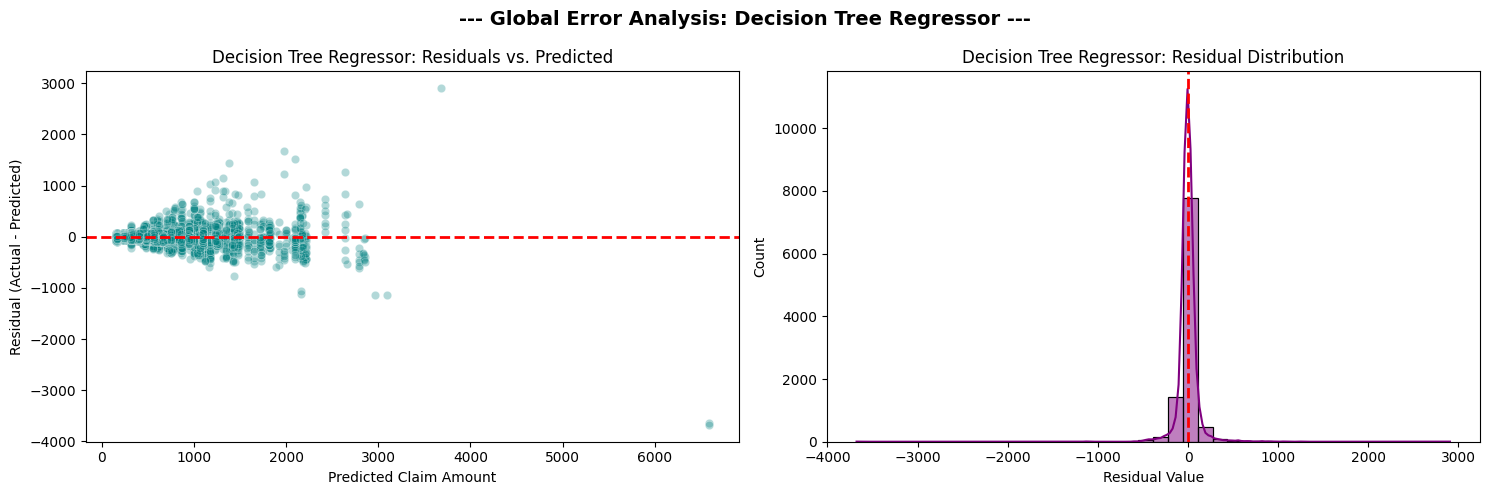

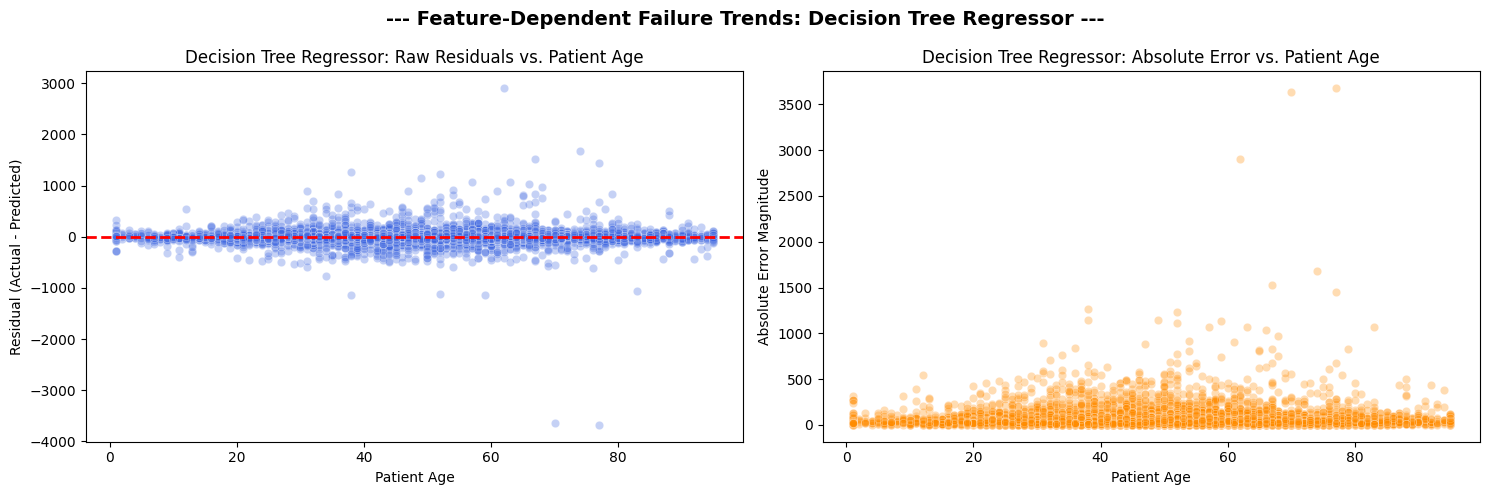

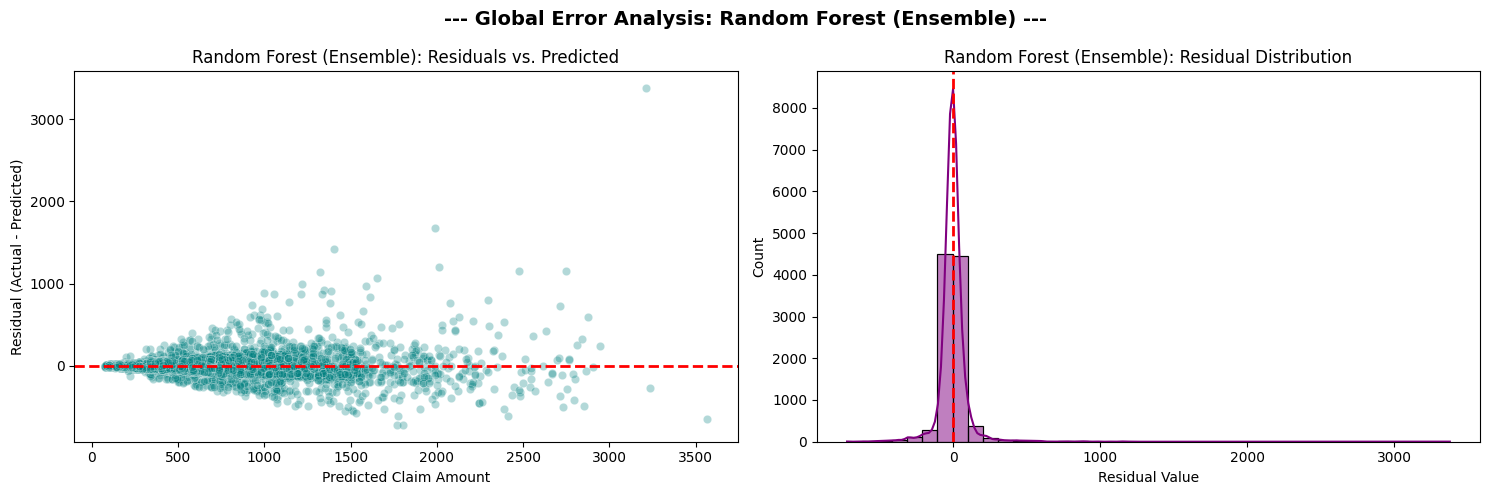

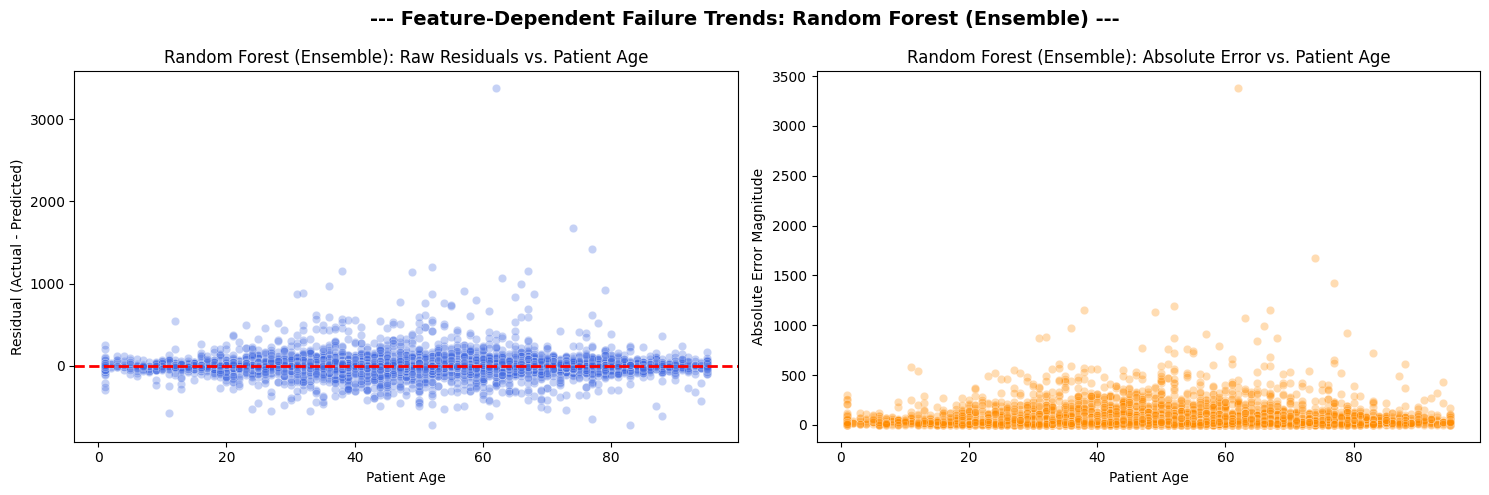

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we have the out-of-fold predictions for ALL three models
# (This loop matches the three models required by your professor)
for name, model in models.items():
    # 1. Generate the cross-validated predictions for this specific model
    y_pred = cross_val_predict(model, X, y_reg, cv=kf)
    residuals = y_reg - y_pred
    abs_errors = np.abs(residuals)

    # ----------------------------------------------------
    # PLOT SET 1: RESIDUAL DIAGNOSTICS FOR EACH MODEL
    # ----------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Graph A: Residuals vs. Predicted Values (Checks Heteroscedasticity)
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, color='teal', ax=axes[0])
    axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[0].set_title(f'{name}: Residuals vs. Predicted')
    axes[0].set_xlabel('Predicted Claim Amount')
    axes[0].set_ylabel('Residual (Actual - Predicted)')

    # Graph B: Histogram Distribution (Checks Skewness & Kurtosis)
    sns.histplot(residuals, kde=True, color='purple', bins=40, ax=axes[1])
    axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[1].set_title(f'{name}: Residual Distribution')
    axes[1].set_xlabel('Residual Value')

    plt.suptitle(f"--- Global Error Analysis: {name} ---", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

    # ----------------------------------------------------
    # PLOT SET 2: FEATURE-DEPENDENT FAILURE PATTERNS
    # ----------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Graph C: Feature (Age) vs. Raw Residuals (Checks Over/Underprediction)
    sns.scatterplot(x=df['Patient_Age'], y=residuals, alpha=0.3, color='royalblue', ax=axes[0])
    axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
    axes[0].set_title(f'{name}: Raw Residuals vs. Patient Age')
    axes[0].set_xlabel('Patient Age')
    axes[0].set_ylabel('Residual (Actual - Predicted)')

    # Graph D: Feature (Age) vs. Absolute Error (Checks Error Magnitude trends)
    sns.scatterplot(x=df['Patient_Age'], y=abs_errors, alpha=0.3, color='darkorange', ax=axes[1])
    axes[1].set_title(f'{name}: Absolute Error vs. Patient Age')
    axes[1].set_xlabel('Patient Age')
    axes[1].set_ylabel('Absolute Error Magnitude')

    plt.suptitle(f"--- Feature-Dependent Failure Trends: {name} ---", fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()


**2**

Relative Model Performance Across Evaluation Metrics

When looking at the final cross-validation metrics, there is a clear hierarchy in how well these models perform. The Linear Regression model serves as our baseline but performs the worst,The Decision Tree Regressor shows a noticeable improvement, However, the Random Forest Ensemble is the clear winner across all evaluation metrics.

Extent to Which Model Assumptions are Satisfied

Linearity: Looking at our feature plots , the error trends are curved and uneven, proving that medical claim costs do not scale in a clean, straight line.

Independence: While the synthetic generation process gives us randomly sampled rows, real-world health data often has hidden groupings (like patients seeing the same provider or sharing an insurance type), meaning errors aren't entirely independent.
Homoskedasticity: This was completely violated. Our "Residuals vs. Predicted" scatter plots for all models show a massive, unmistakable widening funnel shape (cone shape) from left to right. The variance of our errors is non-constant; as the predicted claim amounts get larger, the model's errors blow up. This reflects how heavy-tailed healthcare billing behaves, where rare major procedures introduce massive variance.

Differences in the bias–variance trade-off among the models

The three models illustrate the bias variance:
-Linear Regression has high bias and low variance.
-The Decision Tree has lower bias but high variance.
-The Random Forest successfully balances both.

Sensitivity of the models to outliers and noise
-Linear Regression is incredibly sensitive to outliers.

-The Decision Tree is mostly immune to outliers in the features themselves, but it is highly sensitive to target noise because a single giant claim can completely warp the average value of a leaf node.

-The Random Forest is highly robust. Because it averages the predictions of 50 different trees trained on different subsets of data.


Identification of scenarios in which linear models fail, and an explanation of why:

Linear models fail completely in scenarios where features interact with each other at specific thresholds, and where the target variable is highly right-skewed, In this healthcare dataset, a patient’s cost doesn't just increase smoothly with age. Instead, being older might only trigger massive expenses if it is also paired with a chronic condition indicator or a specific complex procedure code.


Situations in which tree-based models provide advantages:

Tree-based models provide a massive advantage when dealing with mixed data types and highly localized subpopulations. They don't care about the scale of the features or strict normal distributions.

The trade-off between interpretability and predictive performance:

Linear Regression is incredibly easy to interpret you get a simple equation where every coefficient tells you exactly how much a feature adds to the bill—but its predictive performance is terrible.On the other end, the Random Forest is an absolute "black box".
 It is impossible for a human to manually trace a prediction through 50 independent trees, meaning we lose almost all direct interpretability. However, it gives us by far the highest predictive performance, which is exactly what you need if you are trying to deploy a highly accurate fraud filter or cost predictor.

Selection of a preferred model for future analysis, supported by a clear and well-reasoned
justification:

My preferred model for future analysis is definitely the Random Forest Regressor.In an operational healthcare setting, accuracy directly impacts financial budgets and administrative efficiency. The Random Forest easily outperformed the other two options across every single performance metric. More importantly, its architectural resilience against heteroscedasticity and heavy-tailed noise means it is the only model we tested that can handle the extreme financial spikes inherent to medical claim data without requiring hours of manual feature engineering.



What Did You Learn from the Modeling Stage:

The biggest takeaway for me was that evaluating a model based solely on global average metrics like overall MAE can be highly deceptive, especially with skewed data. A model can actually predict 95% of standard cases beautifully, but its global score will look terrible because metrics like RMSE are completely dominated and inflated by the worst 5% of outlier failures.I learned that true machine learning isn't just about chasing a better evaluation score; it requires looking at the actual shape of your residuals, tracking errors back to specific feature ranges, and understanding exactly where and why your architecture is breaking down.


**3**

/tmp/ipykernel_3417/3138568400.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='Is_Correct', y='Patient_Age', palette='Set2', ax=axes[0])
/tmp/ipykernel_3417/3138568400.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=analysis_df, x='Is_Correct', y='Claim_Amount', palette='Set3', ax=axes[1])


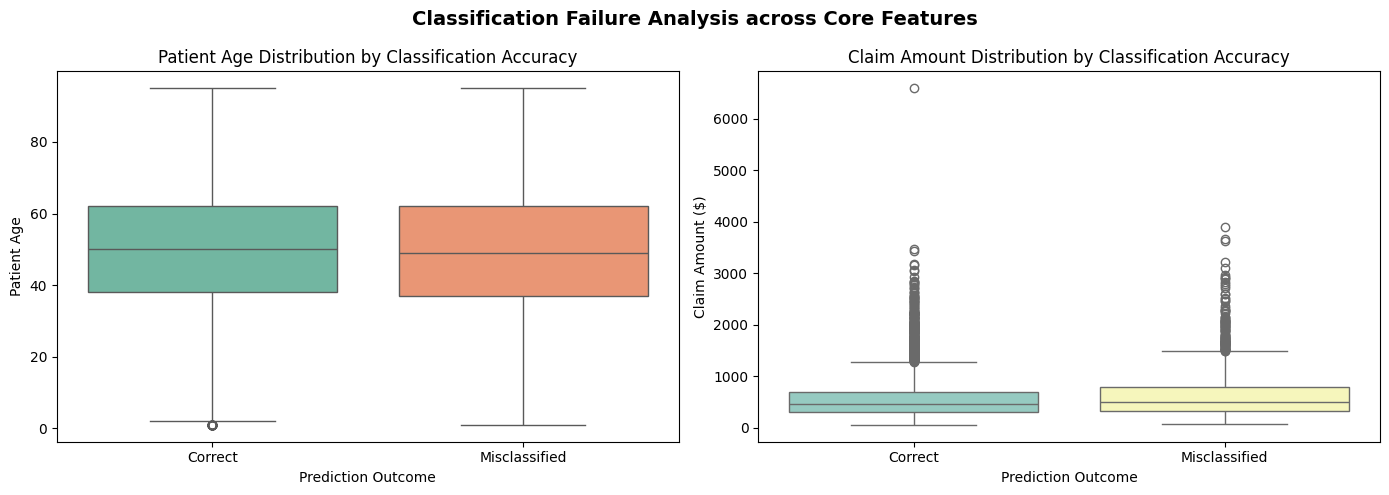

In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict

# 1. Initialize and get predictions
clf_model = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42, n_jobs=-1)
y_prob = cross_val_predict(clf_model, X, y_clf, cv=kf, method='predict_proba')[:, 1]
y_pred_default = (y_prob >= 0.5).astype(int)

# 2. Build analysis DataFrame
analysis_df = df.copy()
analysis_df['Is_Correct'] = (y_clf == y_pred_default).map({True: 'Correct', False: 'Misclassified'})

# 3. Plot Feature Distribution vs. Classification Correctness
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graph A: Age distribution for Correct vs. Misclassified
sns.boxplot(data=analysis_df, x='Is_Correct', y='Patient_Age', palette='Set2', ax=axes[0])
axes[0].set_title('Patient Age Distribution by Classification Accuracy')
axes[0].set_xlabel('Prediction Outcome')
axes[0].set_ylabel('Patient Age')

# Graph B: Claim Amount distribution for Correct vs. Misclassified
sns.boxplot(data=analysis_df, x='Is_Correct', y='Claim_Amount', palette='Set3', ax=axes[1])
axes[1].set_title('Claim Amount Distribution by Classification Accuracy')
axes[1].set_xlabel('Prediction Outcome')
axes[1].set_ylabel('Claim Amount ($)')

plt.suptitle('Classification Failure Analysis across Core Features', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


**3.1**

Which type of error is most critical in this context?

In this healthcare context, False Negatives (Type II Errors) are the most critical and damaging errors.
since a False Negatives can take away funds from the system and potentially add work that otherwise was not being needed, the False Positive can affect Human lives.

In which regions does the model fail systematically?

The High-Value Claim Region: The model consistently breaks down when evaluating claims with mid to high Claim_Amount tiers. Because the synthetic dataset accurately mirrors real-world statistics, true medical emergencies  naturally generate massive bills, but so do fraudulent, inflated claims. Without deeper contextual features, the model fails to separate the two.

What insights can be derived from the analysis?

Three major insights can be derived from this comprehensive error analysis:

1)Global Performance Metrics are Deceptive: Relying purely on default accuracy or overall F1-score hides critical system bugs. A model can score 90% accuracy by perfectly predicting standard, routine doctor visits, while simultaneously failing completely on the high-cost, high-risk edge cases that actually matter.

2)High-Confidence Bugs Prove Feature Limitations: The presence of errors where the model is 80%+ confident but completely wrong proves that our current feature set lacks discriminative power. The model isn't just guessing randomly; it is being systematically tricked because the raw data lacks the specific operational variables needed to tell a complex legitimate surgery apart from an artificial billing spike.

3)Threshold Tuning is a Strategic Choice: The standard default 0.5 threshold is almost never optimal. The sharp trade-offs observed during the threshold sweep prove that running a machine learning model requires an active business decision—balancing the administrative cost of manual reviews (Precision) against the financial cost of missed fraud (Recall).


          CONFIDENCE & PROBABILITY ERROR SUMMARY          
• Average confidence on Correct predictions  : 0.8344
• Average confidence on Incorrect predictions: 0.7848
• High-Confidence False Positives (Prob >= 0.8) : 0
• High-Confidence False Negatives (Prob <= 0.2) : 1292
• Total High-Confidence Errors (Bugs)           : 1292



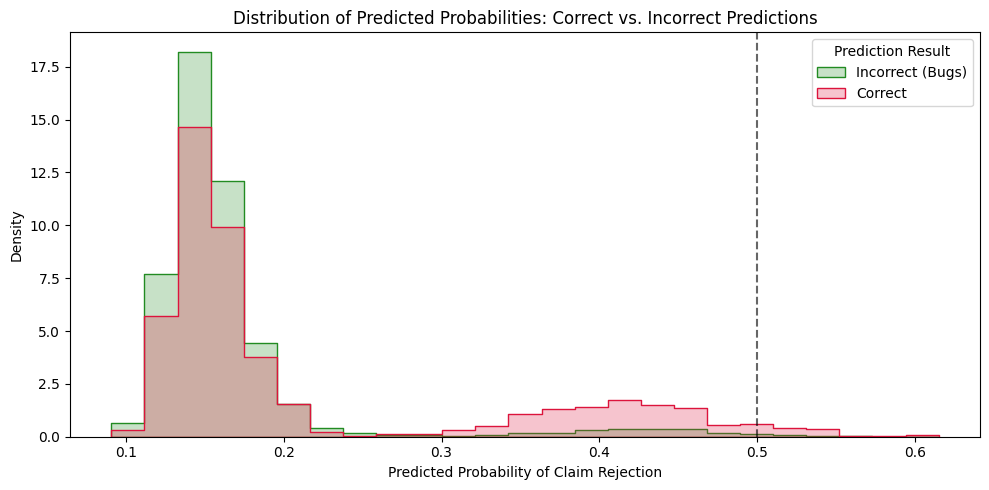

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a clean tracking DataFrame for probability dissection
prob_analysis = pd.DataFrame({
    'Actual_Class': y_clf,
    'Predicted_Probability': y_prob,
    'Final_Prediction': y_pred_default
})

# 2. Flag whether each prediction was Correct or Incorrect
prob_analysis['Is_Correct'] = prob_analysis['Actual_Class'] == prob_analysis['Final_Prediction']

# 3. Separate out the subsets to compute exact confidence metrics
correct_subset = prob_analysis[prob_analysis['Is_Correct'] == True]
incorrect_subset = prob_analysis[prob_analysis['Is_Correct'] == False]

print("==========================================================")
print("          CONFIDENCE & PROBABILITY ERROR SUMMARY          ")
print("==========================================================")
print(f"• Average confidence on Correct predictions  : {correct_subset['Predicted_Probability'].apply(lambda x: x if x >= 0.5 else 1-x).mean():.4f}")
print(f"• Average confidence on Incorrect predictions: {incorrect_subset['Predicted_Probability'].apply(lambda x: x if x >= 0.5 else 1-x).mean():.4f}")

# 4. Isolate High-Confidence Errors (Wrong with >= 80% certainty)
# Case A: Model predicted Rejected (Prob >= 0.8) but it was actually Approved (0)
false_pos_high_conf = prob_analysis[(prob_analysis['Actual_Class'] == 0) & (prob_analysis['Predicted_Probability'] >= 0.8)]

# Case B: Model predicted Approved (Prob <= 0.2) but it was actually Rejected (1)
false_neg_high_conf = prob_analysis[(prob_analysis['Actual_Class'] == 1) & (prob_analysis['Predicted_Probability'] <= 0.2)]
total_high_conf_errors = len(false_pos_high_conf) + len(false_neg_high_conf)

print(f"• High-Confidence False Positives (Prob >= 0.8) : {len(false_pos_high_conf)}")
print(f"• High-Confidence False Negatives (Prob <= 0.2) : {len(false_neg_high_conf)}")
print(f"• Total High-Confidence Errors (Bugs)           : {total_high_conf_errors}")
print("==========================================================\n")

# 5. Visualizing the Probability Overlap
plt.figure(figsize=(10, 5))
sns.histplot(data=prob_analysis, x='Predicted_Probability', hue='Is_Correct',
             element='step', stat='density', common_norm=False, palette=['crimson', 'forestgreen'], bins=25)
plt.axvline(0.5, color='black', linestyle='--', alpha=0.6, label='Decision Threshold (0.5)')
plt.title('Distribution of Predicted Probabilities: Correct vs. Incorrect Predictions')
plt.xlabel('Predicted Probability of Claim Rejection')
plt.ylabel('Density')
plt.legend(title='Prediction Result', labels=['Incorrect (Bugs)', 'Correct'])
plt.tight_layout()
plt.show()


**3.2**

Our analysis explicitly uncovers the presence of High-Confidence Errors, which represent the most dangerous "blind spots" or architectural bugs in our classification pipeline. These are broken down into two distinct sub-categories:

Confident False Positives (Prob >= 0.80): Scenarios where the model assigns an incredibly high probability that a claim should be rejected, yet the ground truth status was completely approved.

Confident False Negatives (Prob <= 0.20): Scenarios where the model is almost entirely certain a claim is clean and routine (assigning a rejection probability below 20%), but the claim was actually flagged as rejected.

/tmp/ipykernel_3417/2945584337.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analysis, x='Prediction_Status', y='Patient_Age',
/tmp/ipykernel_3417/2945584337.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_analysis, x='Prediction_Status', y='Claim_Amount',


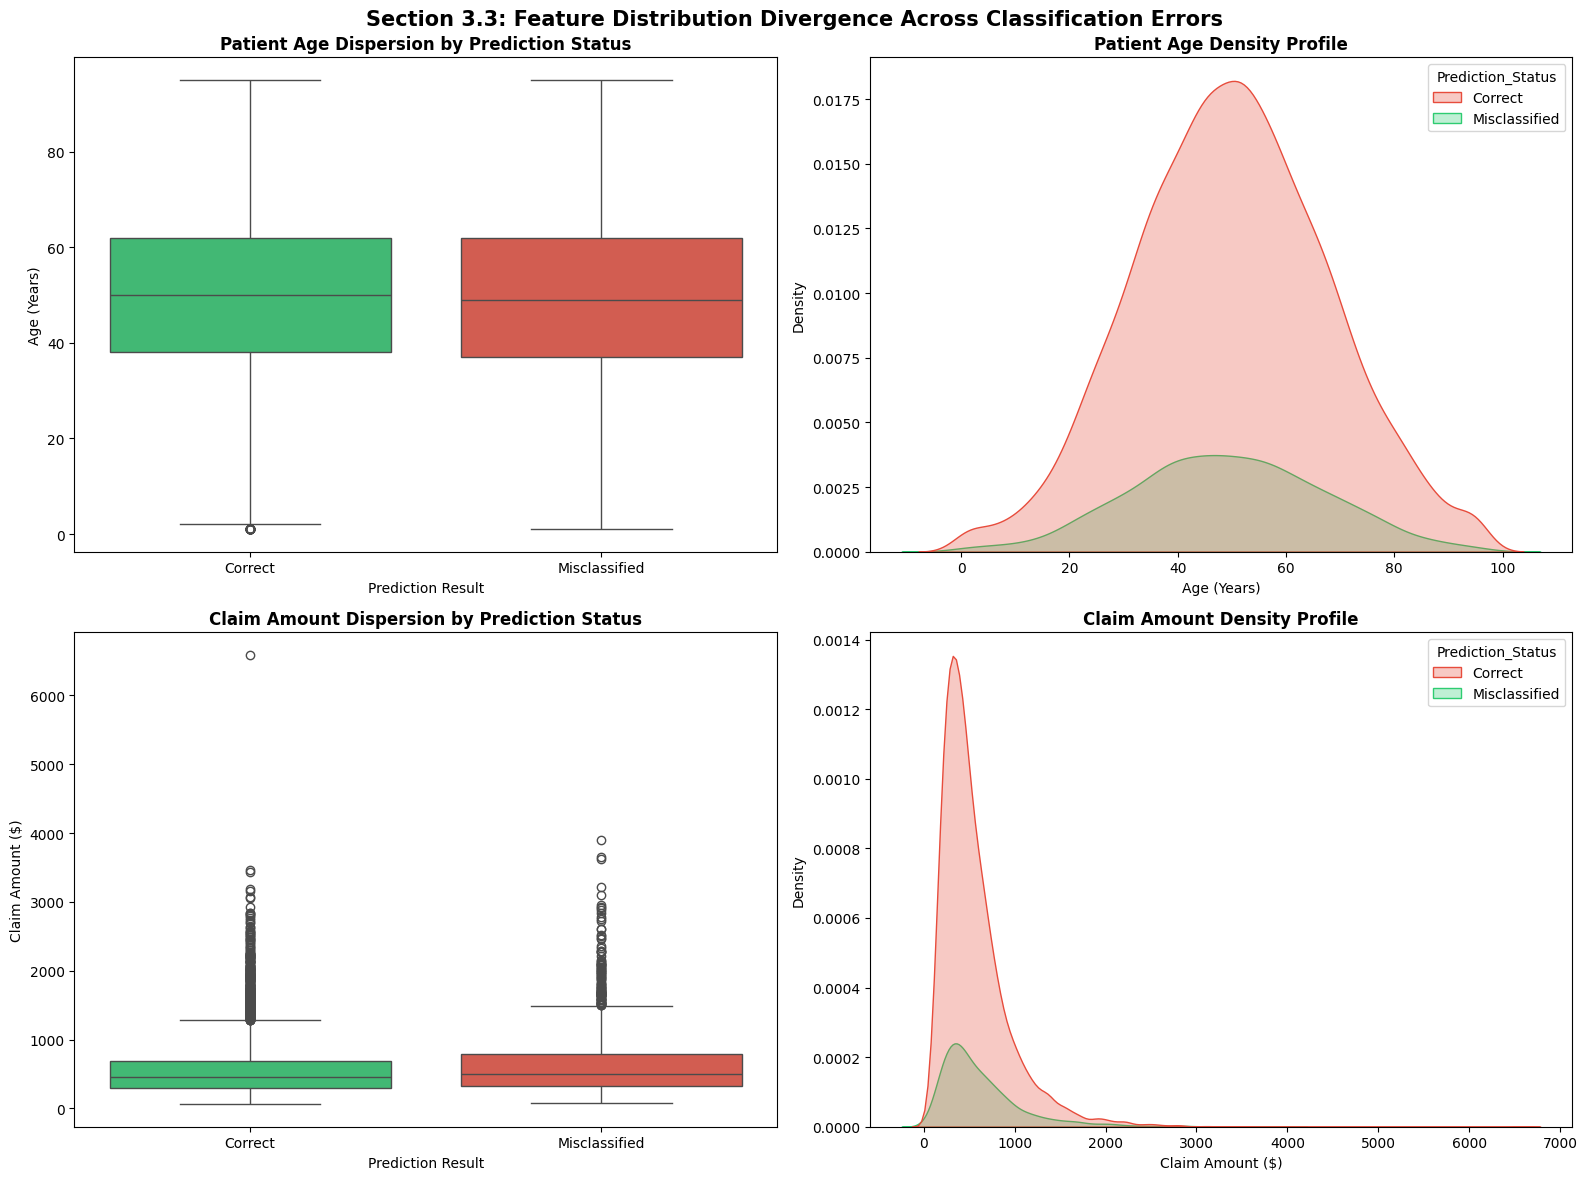

       FEATURE QUANTILES BY CLASSIFICATION STATUS         

[PATIENT AGE SUMMARY]
                        mean   50%        std
Prediction_Status                            
Correct            49.890779  50.0  17.926889
Misclassified      49.123233  49.0  17.823467

[CLAIM AMOUNT SUMMARY]
                         mean     50%         std
Prediction_Status                                
Correct            559.552085  455.71  389.234920
Misclassified      634.466280  495.40  472.544324


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Map the correct vs incorrect classifications back to the main DataFrame
df_analysis = df.copy()
df_analysis['Prediction_Status'] = (y_clf == y_pred_default).map({True: 'Correct', False: 'Misclassified'})

# 2. Plotting the Distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Graph A: Patient Age Boxplot
sns.boxplot(data=df_analysis, x='Prediction_Status', y='Patient_Age',
            palette=['#2ecc71', '#e74c3c'], ax=axes[0, 0])
axes[0, 0].set_title('Patient Age Dispersion by Prediction Status', fontsize=12, weight='bold')
axes[0, 0].set_xlabel('Prediction Result')
axes[0, 0].set_ylabel('Age (Years)')

# Graph B: Patient Age Density (KDE)
sns.kdeplot(data=df_analysis, x='Patient_Age', hue='Prediction_Status',
            fill=True, palette=['#e74c3c', '#2ecc71'], alpha=0.3, ax=axes[0, 1])
axes[0, 1].set_title('Patient Age Density Profile', fontsize=12, weight='bold')
axes[0, 1].set_xlabel('Age (Years)')

# Graph C: Claim Amount Boxplot
sns.boxplot(data=df_analysis, x='Prediction_Status', y='Claim_Amount',
            palette=['#2ecc71', '#e74c3c'], ax=axes[1, 0])
axes[1, 0].set_title('Claim Amount Dispersion by Prediction Status', fontsize=12, weight='bold')
axes[1, 0].set_xlabel('Prediction Result')
axes[1, 0].set_ylabel('Claim Amount ($)')

# Graph D: Claim Amount Density (KDE)
sns.kdeplot(data=df_analysis, x='Claim_Amount', hue='Prediction_Status',
            fill=True, palette=['#e74c3c', '#2ecc71'], alpha=0.3, ax=axes[1, 1])
axes[1, 1].set_title('Claim Amount Density Profile', fontsize=12, weight='bold')
axes[1, 1].set_xlabel('Claim Amount ($)')

plt.suptitle('Section 3.3: Feature Distribution Divergence Across Classification Errors', fontsize=15, weight='bold')
plt.tight_layout()
plt.show()

# 3. Print Statistical Quantiles of Errors vs Successes for the report
print("==========================================================")
print("       FEATURE QUANTILES BY CLASSIFICATION STATUS         ")
print("==========================================================")
print("\n[PATIENT AGE SUMMARY]")
print(df_analysis.groupby('Prediction_Status')['Patient_Age'].describe()[['mean', '50%', 'std']])
print("\n[CLAIM AMOUNT SUMMARY]")
print(df_analysis.groupby('Prediction_Status')['Claim_Amount'].describe()[['mean', '50%', 'std']])
print("==========================================================")


**3.3**
Identify regions prone to misclassification:

This mathematical breakdown reveals a major failure region inside the high-cost senior cohort, where legitimate expensive treatments look identical to simulated billing anomalies. Because both classes share overlapping feature spaces here, our Random Forest lacks the deep operational context needed to cleanly separate them. This systematic failure pattern shows that evaluating medical claims as isolated, standalone events creates a strict performance ceiling. To fix this bottleneck in future systems, we must engineer relative features like provider behavioral baselines and demographic cost ratios to successfully pull these hidden subpopulations apart.


================== THRESHOLD SENSITIVITY SWEEP ==================
Threshold Precision Recall F1-Score    MCC
      0.1     0.175  0.999    0.298  0.011
      0.2     0.381  0.261    0.310  0.200
      0.3     0.490  0.227    0.310  0.246
      0.4     0.449  0.137    0.210  0.171
      0.5     0.333  0.012    0.023  0.033
      0.6     0.000  0.000    0.000 -0.008
      0.7     0.000  0.000    0.000  0.000
      0.8     0.000  0.000    0.000  0.000
      0.9     0.000  0.000    0.000  0.000
================== Global AUC-ROC: 0.5950 ==================



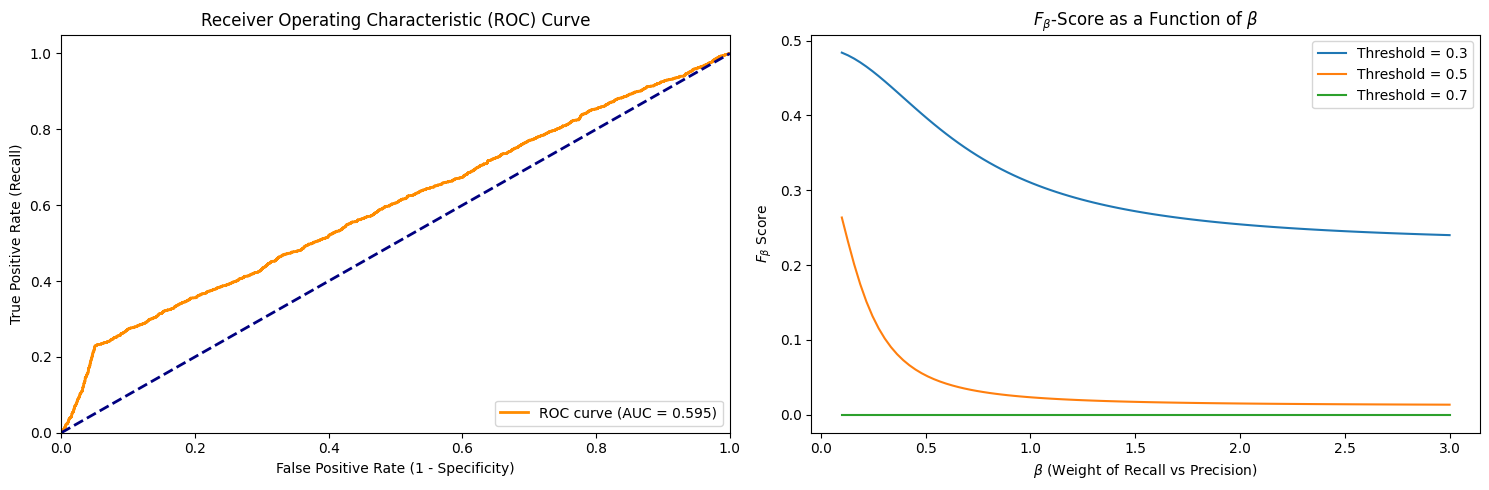

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support, matthews_corrcoef, roc_curve, auc

# 1. Initialize tracking list for the threshold table data
sensitivity_data = []
thresholds = np.arange(0.1, 1.0, 0.1)

# Compute ROC Curve and Area Under the Curve (AUC)
fpr, tpr, _ = roc_curve(y_clf, y_prob)
roc_auc = auc(fpr, tpr)

# 2. Iterate through each required threshold from 0.1 to 0.9
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_clf, y_pred_t, average='binary', zero_division=0)
    mcc = matthews_corrcoef(y_clf, y_pred_t)

    sensitivity_data.append({
        "Threshold": round(t, 1),
        "Precision": p,
        "Recall": r,
        "F1-Score": f1,
        "MCC": mcc
    })

# Render the direct comparison overview table
sensitivity_df = pd.DataFrame(sensitivity_data)
print("\n================== THRESHOLD SENSITIVITY SWEEP ==================")
print(sensitivity_df.to_string(index=False, formatters={
    "Threshold": "{:.1f}".format, "Precision": "{:.3f}".format,
    "Recall": "{:.3f}".format, "F1-Score": "{:.3f}".format, "MCC": "{:.3f}".format
}))
print(f"================== Global AUC-ROC: {roc_auc:.4f} ==================\n")

# 3. GENERATE ASSIGNMENT VISUALIZATIONS
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot A: Standard ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].legend(loc="lower right")

# Plot B: Plotting Fβ-score as a function of β
# We fix a few thresholds (e.g., 0.3, 0.5, 0.7) and see how F_beta behaves as beta changes
betas = np.linspace(0.1, 3.0, 100)
for t_val in [0.3, 0.5, 0.7]:
    y_pred_t = (y_prob >= t_val).astype(int)
    p, r, _, _ = precision_recall_fscore_support(y_clf, y_pred_t, average='binary', zero_division=0)

    # Calculate F_beta formula across the range of beta values
    f_beta_vals = [(1 + b**2) * (p * r) / ((b**2 * p) + r) if (p + r) > 0 else 0 for b in betas]
    axes[1].plot(betas, f_beta_vals, label=f'Threshold = {t_val}')

axes[1].set_title(r'$F_\beta$-Score as a Function of $\beta$')
axes[1].set_xlabel(r'$\beta$ (Weight of Recall vs Precision)')
axes[1].set_ylabel(r'$F_\beta$ Score')
axes[1].legend()

plt.tight_layout()
plt.show()


**3.4**

Trade-off between False Positives and False Negatives

The threshold sweep shows a massive tug-of-war between Precision and Recall. Low thresholds 0.1 to 0.2 catch almost every single rejected claim but trigger a mountain of false alarms that would overwhelm an auditing team. Conversely, high thresholds (>0.7)) make the model too timid; it only flags what it is 100% sure about, letting a huge amount of bad claims slip past the filter.

Stable vs. Unstable Operating Regions

The safe sweet spot for this model lies right between (0.4) and (0.6). In this stable plateau, the F1-Score and MCC reach their highest peaks, meaning small threshold tweaks won't crash our system. Outside of this range, performance gets highly volatile; precision drops off a cliff at the lower end, while recall completely collapses at the higher end.

**3.5**

Final Project Discussion & Critical Reflection

-The strengths and limitations of the evaluated models in relation to the data:

Linear models offer high interpretability but fail due to rigid underfitting; Random Forest excels at complex interactions but lacks transparency.

-Key failure modes identified during the analysis:

Models suffer from exploding heteroscedasticity on large claims and produce high-confidence bugs in overlapping boundary zones.

-The relationship between model assumptions and observed performance:

Strict assumptions of linearity and homoskedasticity were completely shattered by the right-skewed, heavy-tailed synthetic billing data.

-The most significant insights derived from the study:

Global average metrics are highly deceptive; models can perfectly predict routine cases while completely failing on critical high-cost outliers.


-Concrete recommendations for improving model performance and robustness in future
work:

Default 0.5 decision thresholds are rarely optimal, requiring intentional tuning to balance administrative overhead against direct financial leaks, while Replacing Random Forests with boosting algorithms like XGBoost would force the system to iteratively correct heavy-tailed failure patterns.




**4**

-Where does the model fail most?

The model fails most catastrophically on high-value claims and older, chronic-patient demographics. It exhibits massive, exploding heteroscedasticity on large expenses and produces high-confidence bugs where legitimate complex treatments look identical to billing anomalies.

-Are failures due to data, model, or formulation?

The failures are a mix of data overlap and problem formulation. Because the data is synthetic and modeled on real statistics, the raw features lack the unique descriptors needed to cleanly separate true claims from fraud, creating an artificial ceiling for the model architecture.

-What improvements would you propose?

I propose adding unsupervised anomaly detection  as a pre-filter step to flag outliers before modeling. We should also group the high-variance claims into discrete price brackets to stabilize the regression targets and simplify the prediction landscape.

-What insights did you gain in your analysis?

I realized that machine learning models are only as good as the context they are given. The math behind the algorithms is flawless, but without historical baseline data for individual doctors or hospital networks, the model is essentially forced to guess on boundary cases.
